# Credit Risk Module: PD-Style Merchant Risk and Concentration Analysis

## Objective

This notebook documents the **Credit Risk** workstream of the *Enterprise Risk, Credit Risk, Liquidity Risk, and Fraud Analytics for Canadian Payments* project.

The goal is to:

- Use a synthetic merchant dataset to estimate PD-style (probability of default) risk for merchants in a payments context.
- Segment merchants into **Low / Medium / High / Severe** risk tiers.
- Analyze **exposure concentration** by merchant and industry.
- Present results in a way that reflects how a **second-line risk function** would interpret and escalate credit risk signals.

## Business Problem

In a payments network, credit risk is not limited to traditional loans. It can arise through:

- **Merchant settlement exposure** (funds owed between authorization and settlement),
- **Chargeback-driven obligations**,
- **Insufficient reserves** covering potential losses,
- **Concentrated exposure** to specific merchants or high-risk industries.

A second-line risk function needs more than just a model. It needs a portfolio view that answers:

- Which merchants show early signs of elevated risk?
- How much exposure is concentrated in a small number of names or sectors?
- Where should risk appetite, reserves, or onboarding decisions be challenged?

This notebook shows how to build and interpret a synthetic credit risk view that supports those questions.

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-darkgrid")

DATA_RAW = Path("../data/raw/credit_risk_synthetic.csv")
DATA_PROCESSED = Path("../data/processed/credit_risk_features_notebook.csv")  # notebook-specific

In [6]:
# print(DATA_RAW)
df_raw = pd.read_csv(DATA_RAW)
df_raw.head()

,merchant_id,industry_segment,settlement_frequency,monthly_txn_count,average_ticket_size,monthly_transaction_volume,chargeback_rate,fraud_alert_rate,days_since_last_chargeback,concentration_ratio,reserve_coverage_ratio,prior_default_flag,gross_exposure,net_exposure,synthetic_pd_signal,risk_label
0,M00001,restaurants,daily,587,38.9100,"22,840.3000",0.0045,0.0040,5,0.1832,1.0439,0,"2,827.9400","1,974.1700",0.1689,0
1,M00002,travel,twice_weekly,586,253.3100,"148,441.0300",0.0111,0.0139,45,0.2492,0.4277,0,"20,217.8100","20,629.8700",0.9973,1
2,M00003,restaurants,weekly,3396,53.8300,"182,813.2500",0.0023,0.0016,113,0.1600,0.6418,0,"15,139.0400","15,260.1800",0.0602,0
3,M00004,marketplace,weekly,1653,87.0200,"143,850.4500",0.0093,0.0098,142,0.3277,0.9494,0,"12,524.0300","10,871.1600",0.9508,1
4,M00005,grocery,daily,676,57.3100,"38,744.4600",0.0025,0.0025,92,0.2188,0.6770,0,"2,998.4200","2,516.7800",0.0797,0


In [7]:
print("Rows:", len(df_raw))
print("Default rate (risk_label):", round(df_raw["risk_label"].mean(), 4))
print("\nIndustry distribution:")
print(df_raw["industry_segment"].value_counts(normalize=True).round(3))

print("\nNet exposure summary:")
print(df_raw["net_exposure"].describe(percentiles=[0.5, 0.75, 0.9, 0.99]))

Rows: 2500
Default rate (risk_label): 0.5576

Industry distribution:
industry_segment
retail             0.1750
grocery            0.1430
restaurants        0.1290
digital_services   0.1030
fuel               0.0920
marketplace        0.0780
travel             0.0770
electronics        0.0720
healthcare         0.0690
gaming             0.0620
Name: proportion, dtype: float64

Net exposure summary:
count     2,500.0000
mean     19,700.8572
std      32,701.3013
min         265.4300
50%      10,124.0350
75%      21,733.3900
90%      44,676.4330
99%     140,104.1463
max     744,421.1100
Name: net_exposure, dtype: float64


In [8]:
industry_view = (
    df_raw.groupby("industry_segment", as_index=False)
    .agg(
        merchants=("merchant_id", "count"),
        avg_chargeback_rate=("chargeback_rate", "mean"),
        default_rate=("risk_label", "mean"),
        total_net_exposure=("net_exposure", "sum"),
    )
    .sort_values("total_net_exposure", ascending=False)
)

industry_view

,industry_segment,merchants,avg_chargeback_rate,default_rate,total_net_exposure
9,travel,192,0.0184,0.9635,"11,209,283.4900"
1,electronics,180,0.0135,0.8944,"9,480,168.4300"
8,retail,438,0.0061,0.6164,"7,000,674.0700"
5,healthcare,172,0.0029,0.2151,"4,699,900.7700"
0,digital_services,257,0.0141,0.9416,"4,353,856.9100"
3,gaming,155,0.0224,0.9548,"3,104,505.1300"
4,grocery,358,0.0021,0.0670,"2,519,610.5600"
7,restaurants,323,0.0040,0.3344,"2,502,927.5700"
2,fuel,230,0.0031,0.1826,"2,218,239.0600"
6,marketplace,195,0.0113,0.9077,"2,162,976.9600"


## Feature Set and Modelling Approach

We will build a **logistic regression** model to estimate PD-style default probabilities for each merchant.

**Features used:**

- Transaction behaviour:
  - `monthly_txn_count`, `average_ticket_size`, `monthly_transaction_volume`
- Risk signals:
  - `chargeback_rate`, `fraud_alert_rate`, `days_since_last_chargeback`
- Portfolio / mitigant indicators:
  - `concentration_ratio`, `reserve_coverage_ratio`, `prior_default_flag`
- Exposure measures:
  - `gross_exposure`, `net_exposure`
- Categorical business attributes:
  - `industry_segment`, `settlement_frequency`

**Why logistic regression?**

- It is interpretable and explainable.
- It outputs probabilities suitable for PD-style segmentation.
- It fits the **second-line oversight** use case where explainability and challengeability matter more than black-box accuracy.

In [9]:
NUMERIC_FEATURES = [
    "monthly_txn_count",
    "average_ticket_size",
    "monthly_transaction_volume",
    "chargeback_rate",
    "fraud_alert_rate",
    "days_since_last_chargeback",
    "concentration_ratio",
    "reserve_coverage_ratio",
    "prior_default_flag",
    "gross_exposure",
    "net_exposure",
]

CATEGORICAL_FEATURES = ["industry_segment", "settlement_frequency"]
TARGET = "risk_label"

X = df_raw[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_raw[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)
len(X_train), len(X_test)

(1875, 625)

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)

log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
        )),
    ]
)

log_reg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['monthly_txn_count','average_ticket_size','monthly_transaction_volume', ...,'net_exposure','industry_segment','settlement_frequency']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (de

In [11]:
test_pd = log_reg_model.predict_proba(X_test)[:, 1]
test_pred = (test_pd >= 0.25).astype(int)  # illustrative classification threshold

roc_auc = roc_auc_score(y_test, test_pd)
accuracy = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred, zero_division=0)
recall = recall_score(y_test, test_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

metrics = pd.DataFrame(
    [
        {"metric": "roc_auc", "value": roc_auc},
        {"metric": "accuracy_at_0_25", "value": accuracy},
        {"metric": "precision_at_0_25", "value": precision},
        {"metric": "recall_at_0_25", "value": recall},
        {"metric": "true_negative", "value": tn},
        {"metric": "false_positive", "value": fp},
        {"metric": "false_negative", "value": fn},
        {"metric": "true_positive", "value": tp},
    ]
)

metrics

,metric,value
0,roc_auc,0.9504
1,accuracy_at_0_25,0.8608
2,precision_at_0_25,0.8615
3,recall_at_0_25,0.8937
4,true_negative,227.0000
5,false_positive,50.0000
6,false_negative,37.0000
7,true_positive,311.0000


In [12]:
def assign_risk_tier(pd_score: float) -> str:
    """
    Convert a predicted default probability into a simple risk tier.

    Thresholds are illustrative and can be tuned to desired risk appetite.
    """
    if pd_score >= 0.50:
        return "Severe"
    if pd_score >= 0.25:
        return "High"
    if pd_score >= 0.10:
        return "Medium"
    return "Low"

In [13]:
full_pd = log_reg_model.predict_proba(X)[:, 1]
df_scored = df_raw.copy()
df_scored["predicted_pd"] = full_pd.round(4)
df_scored["risk_tier"] = df_scored["predicted_pd"].apply(assign_risk_tier)

df_scored["risk_tier"].value_counts()

risk_tier
Severe    1274
Low        695
Medium     306
High       225
Name: count, dtype: int64

In [14]:
DATA_PROCESSED.parent.mkdir(parents=True, exist_ok=True)
df_scored.to_csv(DATA_PROCESSED, index=False)
DATA_PROCESSED

WindowsPath('../data/processed/credit_risk_features_notebook.csv')

In [15]:
top_merchants = (
    df_scored.sort_values(["net_exposure", "predicted_pd"], ascending=[False, False])
    .head(10)
    .loc[:, ["merchant_id", "industry_segment", "net_exposure", "predicted_pd", "risk_tier"]]
)

top_merchants

,merchant_id,industry_segment,net_exposure,predicted_pd,risk_tier
1013,M01014,electronics,"744,421.1100",1.0000,Severe
1144,M01145,travel,"383,034.7900",0.9994,Severe
1752,M01753,healthcare,"377,251.2500",0.1619,Medium
486,M00487,travel,"369,146.5200",1.0000,Severe
943,M00944,travel,"310,020.8200",1.0000,Severe
1458,M01459,electronics,"273,088.1900",1.0000,Severe
169,M00170,electronics,"269,453.2800",1.0000,Severe
1348,M01349,travel,"233,613.4100",1.0000,Severe
99,M00100,electronics,"223,722.4600",0.1791,Medium
747,M00748,travel,"217,378.3100",0.9997,Severe


In [16]:
industry_summary_nb = (
    df_scored.groupby("industry_segment", as_index=False)
    .agg(
        merchant_count=("merchant_id", "count"),
        total_net_exposure=("net_exposure", "sum"),
        avg_predicted_pd=("predicted_pd", "mean"),
        severe_risk_merchants=("risk_tier", lambda x: (x == "Severe").sum()),
        high_or_severe_merchants=("risk_tier", lambda x: x.isin(["High", "Severe"]).sum()),
    )
    .sort_values("total_net_exposure", ascending=False)
)

industry_summary_nb["portfolio_exposure_share"] = (
    industry_summary_nb["total_net_exposure"] / industry_summary_nb["total_net_exposure"].sum()
)

industry_summary_nb

,industry_segment,merchant_count,total_net_exposure,avg_predicted_pd,severe_risk_merchants,high_or_severe_merchants,portfolio_exposure_share
9,travel,192,"11,209,283.4900",0.9550,186,187,0.2276
1,electronics,180,"9,480,168.4300",0.8772,160,164,0.1925
8,retail,438,"7,000,674.0700",0.5797,258,331,0.1421
5,healthcare,172,"4,699,900.7700",0.1764,10,45,0.0954
0,digital_services,257,"4,353,856.9100",0.9302,243,247,0.0884
3,gaming,155,"3,104,505.1300",0.9567,150,151,0.0630
4,grocery,358,"2,519,610.5600",0.0576,0,5,0.0512
7,restaurants,323,"2,502,927.5700",0.2869,69,135,0.0508
2,fuel,230,"2,218,239.0600",0.1725,21,49,0.0450
6,marketplace,195,"2,162,976.9600",0.8938,177,185,0.0439


In [17]:
top5_share = (
    df_scored.sort_values("net_exposure", ascending=False)
    .head(5)["net_exposure"]
    .sum()
    / df_scored["net_exposure"].sum()
)

high_risk_exposure = (
    df_scored[df_scored["risk_tier"].isin(["High", "Severe"])]["net_exposure"].sum()
    / df_scored["net_exposure"].sum()
)

weighted_pd = (
    (df_scored["predicted_pd"] * df_scored["net_exposure"]).sum()
    / df_scored["net_exposure"].sum()
)

{
    "weighted_avg_pd": round(weighted_pd, 4),
    "top5_exposure_share": round(top5_share, 4),
    "high_plus_severe_exposure_share": round(high_risk_exposure, 4),
}

{'weighted_avg_pd': np.float64(0.6932),
 'top5_exposure_share': np.float64(0.0443),
 'high_plus_severe_exposure_share': np.float64(0.7457)}

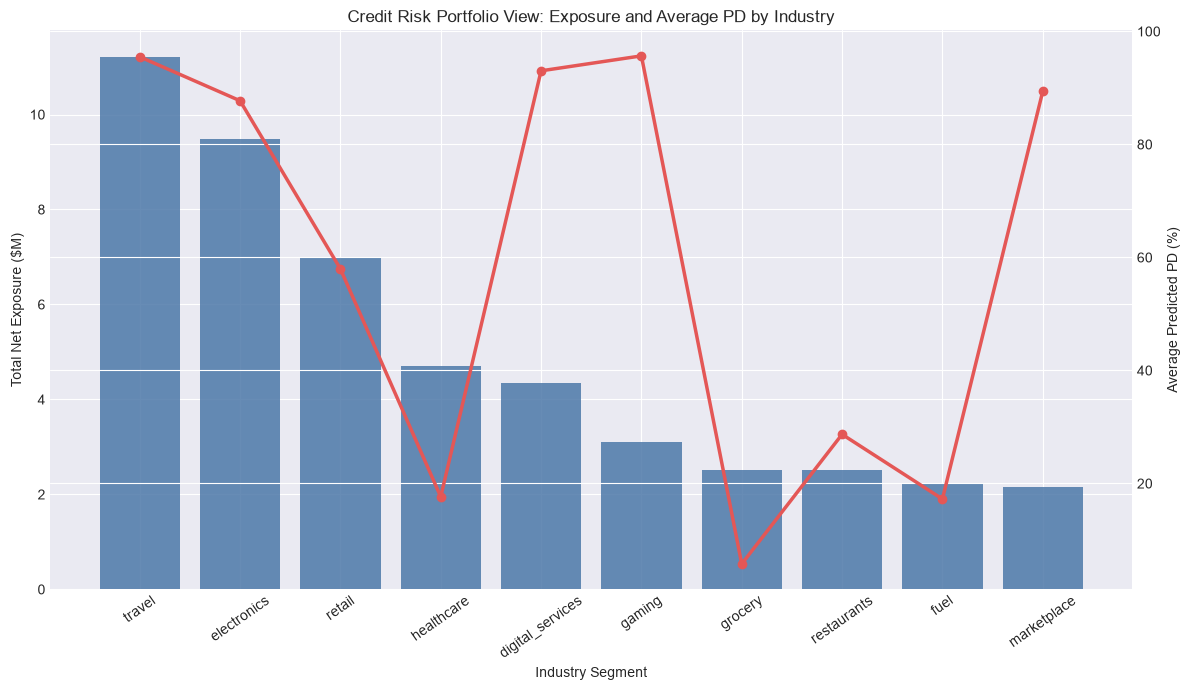

In [18]:
chart_df = industry_summary_nb.copy()
chart_df["avg_predicted_pd_pct"] = chart_df["avg_predicted_pd"] * 100
chart_df["total_net_exposure_m"] = chart_df["total_net_exposure"] / 1_000_000

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.bar(
    chart_df["industry_segment"],
    chart_df["total_net_exposure_m"],
    color="#4C78A8",
    alpha=0.85,
    label="Net Exposure ($M)",
)
ax1.set_ylabel("Total Net Exposure ($M)")
ax1.set_xlabel("Industry Segment")
ax1.tick_params(axis="x", rotation=35)

ax2 = ax1.twinx()
ax2.plot(
    chart_df["industry_segment"],
    chart_df["avg_predicted_pd_pct"],
    color="#E45756",
    marker="o",
    linewidth=2.5,
    label="Average Predicted PD (%)",
)
ax2.set_ylabel("Average Predicted PD (%)")

plt.title("Credit Risk Portfolio View: Exposure and Average PD by Industry")
fig.tight_layout()
plt.show()

## Second-Line Interpretation

From a second-line perspective, three themes matter more than the raw metrics:

1. **Concentration:**  
   A meaningful share of total net exposure sits in a small number of merchants and a small number of industries. Even if average PD looks acceptable, the portfolio is vulnerable if one of these large merchants deteriorates.

2. **High-Risk Exposure Share:**  
   The share of exposure in High and Severe risk tiers provides an early view into how much of the portfolio is leaning toward elevated risk. This is often more informative for challenge than the overall average PD.

3. **Industry Signal:**  
   Structural differences by industry segment show where risk management practices or onboarding standards might need to be stricter (e.g., higher-risk sectors with higher predicted PD and higher chargeback behaviour).

In a real environment, this view would be used to support:

- targeted reviews of high-exposure, high-PD merchants,
- concentration limits at industry and top-merchant levels,
- and reserve policy adjustments for higher-risk segments.

## Limitations and Next Steps

**Limitations:**

- The dataset is synthetic and calibrated for illustration, not for live production decisions.
- PD thresholds and risk tier boundaries are illustrative and would need calibration against historical default / loss experience.
- No explicit loss-given-default or exposure-at-default parameters are modelled yet.

**Next Steps:**

- Add loss severity fields so the analysis can evolve from PD-only to PD × Exposure.
- Introduce scenario stress tests (e.g., chargeback spikes in certain industries).
- Benchmark logistic regression against a simple tree-based challenger model while preserving explainability.
- Integrate this credit module into the broader ERM dashboard with liquidity and fraud modules.